## <img src="logo_UNSAM.jpg" align="right" width="300" height="300"> *Análisis y precesamiento de señales*  
<h3 style="font-weight: normal;">Alumno: Joaquín Rios</h3>
&nbsp;
&nbsp;

## |  Trabajo Semanal N°0




&emsp;&emsp;&emsp; El objetivo de este trabajo semanal es adaptarnos al entorno de desarrollo y redacción **Jupyter Notebook** al utilizarlo para describir los fenómenos observados al variar la frecuencia de una señal sinusoidal  con respecto a una frecuencia de *Sampling* de referencia (En este caso fijada a $500Hz$) y variar la frecuencia de la señal pedida observando qué se ve para cada valor pedido. Adelantándonos y basándonos en la teoría, se observará que ocurre cerca, muy lejos y exactamente *en* la **frecuencia de Nyquist**.

&emsp;&emsp;&emsp; En esta oportunidad los parámetro de la señal los mantendremos constantes salvo la frecuencia de esta. Definimos una función con los siguientes parámetros &nbsp;
- La amplitud máxima de la senoidal (volts)
- Su valor medio o componente de contínua (volts)
- La frecuencia (Hz)
- La fase (radianes)
- La cantidad de muestras digitalizada por el ADC (# muestras)
- La frecuencia de muestreo del ADC.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

fs=500
N=1000

def mi_funcion_sen(vmax= 1, dc=0, ff=1, ph=0, nn=N, fs=fs):
    xx = vmax * np.sin(2*np.pi*ff*nn/fs + ph) + dc
    tt = np.arange(0,N)/fs
    
    return(tt, xx)


&emsp;&emsp;&emsp; Una vez definida la función probamos las distintas frecuencias dadas en la consigna, las cuales son : $500Hz, 999Hz, 1001Hz$ y  $2001Hz$. Es necesario entender, antes de empezar a evaluar los resultados, dos detalles importantes. Primero debemos entender que Nyquist propone a la frecuencia de muestreo como, por lo menos, dos veces más que la frecuencia máxima de mi señal. Despejando con la frecuecia de Nyquist nos quedaría una expresión del tipo $sin (πn)$, la cual claramente vemos que siempre dará $0$, por lo que idealmente al visualizar la función no deberíamos ver nada, pero en la realidad toma valores muy cercanos a cero pero no nulos, por lo que el ploteo (por cómo se grafica en python) muestra representaciones irrisorias. 



&emsp;&emsp;&emsp; Probamos con   $ff = 500 Hz$ : 

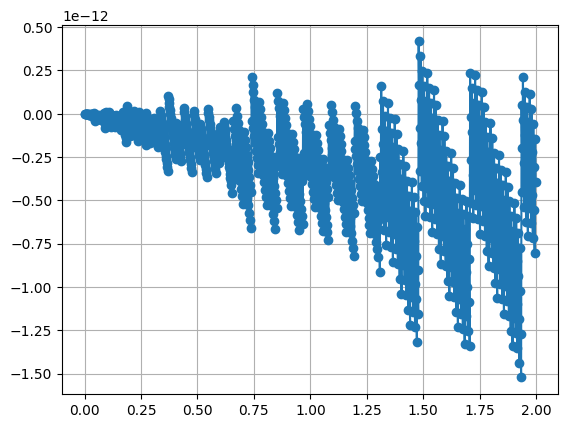

In [7]:
nn = nn=np.arange(N)
tt, xx = mi_funcion_sen(ff=500,nn = nn)

plt.plot(tt, xx, 'o-')
plt.grid()
plt.show()

&emsp;&emsp;&emsp; Lo que previmos anteriormente está sucediendo, la forma de senoidal se pierde y, al no ser exacto el cero del computo, la señal se comporta de manera errática

&emsp;&emsp;&emsp; Probamos con   $ff = 1001 Hz$ : 

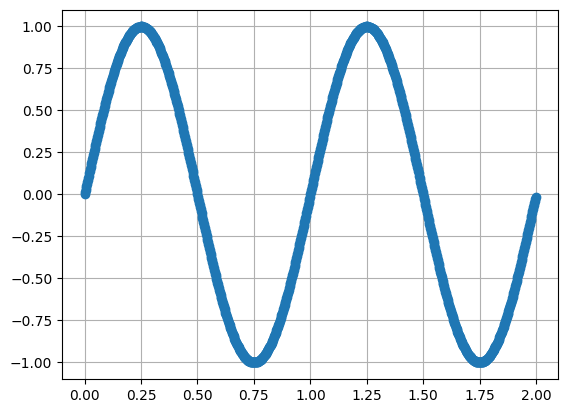

In [10]:
nn = nn=np.arange(N)
tt, xx = mi_funcion_sen(ff=1001,nn = nn)

plt.plot(tt, xx, 'o-')
plt.grid()
plt.show()

&emsp;&emsp;&emsp; Este caso es particular ya que como bien sabemos, al pasar de un tiempo contínuo a uno discreto mediante DTFT, generamos una periodicidad en el espectro de frecuencias, y lo que vemos acá es el inicio del siguente período, es decir, que esta señal es equivalente a usar una $ff = 1 Hz$

&emsp;&emsp;&emsp; Probamos con   $ff = 2001 Hz$ : 

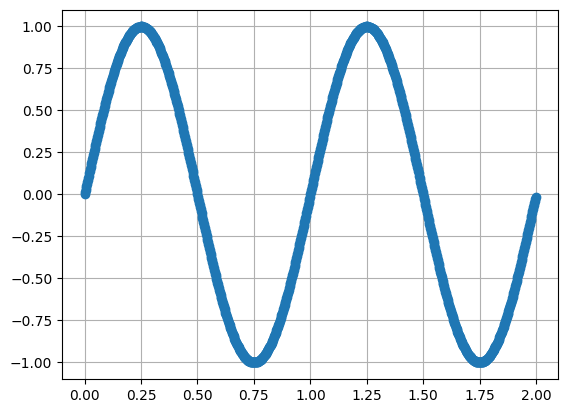

In [11]:
nn = nn=np.arange(N)
tt, xx = mi_funcion_sen(ff=2001,nn = nn)

plt.plot(tt, xx, 'o-')
plt.grid()
plt.show()

&emsp;&emsp;&emsp; Este es un ejemplo idéntico al anterior, no hay mucho que comentar.

&emsp;&emsp;&emsp; Probamos con   $ff = 999 Hz$ : 

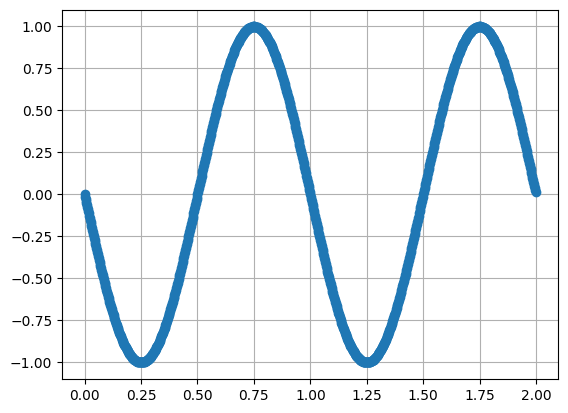

In [9]:
nn = nn=np.arange(N)
tt, xx = mi_funcion_sen(ff=999,nn = nn)

plt.plot(tt, xx, 'o-')
plt.grid()
plt.show()

&emsp;&emsp;&emsp; Ahora podemos hablar de lo que conocemos como el recíproco conjugado de nuestro **X[n]**. Este se refiere al n cuyo módulo es igual, pero que varía la fase en $180°$ 

&emsp;&emsp;&emsp; Por último pasamos a construir una señal distinta a una sinusoide, en mi caso decidí construir con una serie de comandos un **tren de pulsos** con la libreria Numpy

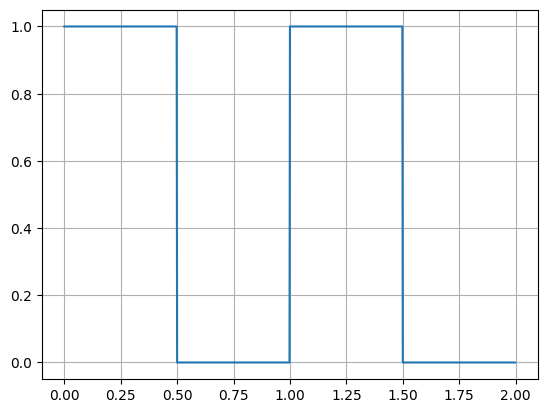

In [13]:
def mi_funcion_pulsos(vmax=1, dc=0, ff=1, duty=0.5, nn=N, fs=fs):
    tt = nn / fs
    T = 1 / ff
    
    xx = np.where((tt % T) < duty*T, vmax, dc)
    
    return tt, xx

nn = np.arange(N)

tt, xx = mi_funcion_pulsos(ff=1, duty=0.5, nn=nn, fs=fs)

plt.plot(tt, xx)
plt.grid()
plt.show()

&emsp;&emsp;&emsp; Esta señal como bien sabemos es parte del repertorio de un generador de señales, aquí variamos tanto la frecuencia de la señal como lo que se conoce como **Duty Cycle**, el cual habla de cuanto tiempo la señal se encuentra en lo que se llama estado alto ( $1$ lógico), y en cuanto en estado bajo ($0$ lógico) con respecto al período de la misma.